In [2]:
!pip install -q kagglehub

In [3]:
from google.colab import files
import os
import shutil

print("Upload kaggle.json")
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.copy(
    "kaggle.json",
    "/root/.kaggle/kaggle.json"
)

os.chmod(
    "/root/.kaggle/kaggle.json",
    0o600
)

print("✅ Kaggle configured")

Upload kaggle.json


Saving kaggle.json to kaggle.json
✅ Kaggle configured


In [4]:
import kagglehub

datasets = {
    "17_class": "fernando2rad/brain-tumor-mri-images-17-classes",
    "44_class": "fernando2rad/brain-tumor-mri-images-44c"
}

dataset_paths = {}

for name, dataset_id in datasets.items():

    print("\n" + "=" * 70)
    print("Downloading:", dataset_id)
    print("=" * 70)

    path = kagglehub.dataset_download(dataset_id)

    dataset_paths[name] = path

    print("Downloaded to:")
    print(path)


Downloading: fernando2rad/brain-tumor-mri-images-17-classes


100%|██████████| 197M/197M [00:10<00:00, 19.7MB/s]

Extracting files...


Downloaded to:
/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-17-classes/versions/1

Downloading: fernando2rad/brain-tumor-mri-images-44c


100%|██████████| 188M/188M [00:10<00:00, 19.2MB/s]

Extracting files...


Downloaded to:
/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-44c/versions/1


In [5]:
!wget -q -O /content/figshare_brain_tumor.zip \
"https://figshare.com/ndownloader/articles/1512427/versions/5"

print("Downloaded Figshare archive")

Downloaded Figshare archive


In [6]:
!mkdir -p /content/figshare_brain_tumor
!unzip -q /content/figshare_brain_tumor.zip -d /content/figshare_brain_tumor

[/content/figshare_brain_tumor.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/figshare_brain_tumor.zip or
        /content/figshare_brain_tumor.zip.zip, and cannot find /content/figshare_brain_tumor.zip.ZIP, period.


In [7]:
from pathlib import Path

def show_tree(root, max_depth=3):

    root = Path(root)

    print("\nROOT:", root)

    for item in sorted(root.rglob("*")):

        relative = item.relative_to(root)

        if len(relative.parts) <= max_depth:

            if item.is_dir():
                print("📁", relative)

            else:
                print("📄", relative)


for name, path in dataset_paths.items():

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    show_tree(path, max_depth=3)


print("\n" + "=" * 80)
print("FIGSHARE")
print("=" * 80)

show_tree("/content/figshare_brain_tumor", max_depth=3)

Streaming output truncated to the last 5000 lines.
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (103).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (104).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (105).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (106).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (107).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (108).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (109).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (11).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (11).jpg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (110).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (111).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (112).jpeg
📄 Schwannoma (Acustico, Vestibular - Trigeminal) T1/schwannoma (

In [8]:
from pathlib import Path
from collections import Counter

ROOT_44 = Path(
    "/root/.cache/kagglehub/datasets/"
    "fernando2rad/brain-tumor-mri-images-44c/versions/1"
)

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

class_counts = {}

for folder in sorted(ROOT_44.iterdir()):

    if not folder.is_dir():
        continue

    count = sum(
        1
        for f in folder.rglob("*")
        if f.is_file() and f.suffix.lower() in image_extensions
    )

    class_counts[folder.name] = count


print("=" * 70)
print("44-CLASS MRI DATASET")
print("=" * 70)

total = 0

for cls, count in sorted(
    class_counts.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{cls:<55} {count:>6}")
    total += count

print("=" * 70)
print(f"TOTAL IMAGES: {total}")
print(f"TOTAL CLASSES: {len(class_counts)}")

44-CLASS MRI DATASET
Meningioma T1C+                                            369
Meningioma T1                                              272
_NORMAL T2                                                 271
_NORMAL T1                                                 251
Astrocitoma T1C+                                           233
Meningioma T2                                              233
Neurocitoma T1C+                                           223
Schwannoma T1C+                                            194
Astrocitoma T1                                             176
Astrocitoma T2                                             171
Schwannoma T1                                              148
Neurocitoma T1                                             130
Schwannoma T2                                              123
Carcinoma T1C+                                             112
Papiloma T1C+                                              108
Neurocitoma T2                    

In [9]:
print("\nClasses:")
for i, cls in enumerate(sorted(class_counts)):
    print(f"{i:2d} -> {cls}")


Classes:
 0 -> Astrocitoma T1
 1 -> Astrocitoma T1C+
 2 -> Astrocitoma T2
 3 -> Carcinoma T1
 4 -> Carcinoma T1C+
 5 -> Carcinoma T2
 6 -> Ependimoma T1
 7 -> Ependimoma T1C+
 8 -> Ependimoma T2
 9 -> Ganglioglioma T1
10 -> Ganglioglioma T1C+
11 -> Ganglioglioma T2
12 -> Germinoma T1
13 -> Germinoma T1C+
14 -> Germinoma T2
15 -> Glioblastoma T1
16 -> Glioblastoma T1C+
17 -> Glioblastoma T2
18 -> Granuloma T1
19 -> Granuloma T1C+
20 -> Granuloma T2
21 -> Meduloblastoma T1
22 -> Meduloblastoma T1C+
23 -> Meduloblastoma T2
24 -> Meningioma T1
25 -> Meningioma T1C+
26 -> Meningioma T2
27 -> Neurocitoma T1
28 -> Neurocitoma T1C+
29 -> Neurocitoma T2
30 -> Oligodendroglioma T1
31 -> Oligodendroglioma T1C+
32 -> Oligodendroglioma T2
33 -> Papiloma T1
34 -> Papiloma T1C+
35 -> Papiloma T2
36 -> Schwannoma T1
37 -> Schwannoma T1C+
38 -> Schwannoma T2
39 -> Tuberculoma T1
40 -> Tuberculoma T1C+
41 -> Tuberculoma T2
42 -> _NORMAL T1
43 -> _NORMAL T2


In [10]:
from pathlib import Path
import shutil
import random
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

SOURCE = Path(
    "/root/.cache/kagglehub/datasets/"
    "fernando2rad/brain-tumor-mri-images-44c/versions/1"
)

OUTPUT = Path("/content/MRI_12_CLASS")

SEED = 42
random.seed(SEED)

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

# ============================================================
# 12 CLASSES WE DECIDED TO KEEP
# ============================================================

KEEP_CLASSES = [
    "Astrocitoma",
    "Carcinoma",
    "Ependimoma",
    "Germinoma",
    "Glioblastoma",
    "Meduloblastoma",
    "Meningioma",
    "Neurocitoma",
    "Oligodendroglioma",
    "Papiloma",
    "Schwannoma",
    "_NORMAL"
]

# Classes deliberately removed
REMOVE_CLASSES = [
    "Ganglioglioma",
    "Granuloma",
    "Tuberculoma"
]

# ============================================================
# CLASS NAME CONVERSION
# ============================================================

DISPLAY_NAMES = {
    "Astrocitoma": "Astrocitoma",
    "Carcinoma": "Carcinoma",
    "Ependimoma": "Ependimoma",
    "Germinoma": "Germinoma",
    "Glioblastoma": "Glioblastoma",
    "Meduloblastoma": "Meduloblastoma",
    "Meningioma": "Meningioma",
    "Neurocitoma": "Neurocitoma",
    "Oligodendroglioma": "Oligodendroglioma",
    "Papiloma": "Papiloma",
    "Schwannoma": "Schwannoma",
    "_NORMAL": "Normal"
}

# ============================================================
# COLLECT IMAGES
# ============================================================

class_images = defaultdict(list)

ignored_folders = []

for folder in sorted(SOURCE.iterdir()):

    if not folder.is_dir():
        continue

    folder_name = folder.name

    # --------------------------------------------------------
    # Determine the disease class.
    #
    # Examples:
    # Meningioma T1       -> Meningioma
    # Meningioma T1C+     -> Meningioma
    # Meningioma T2       -> Meningioma
    # _NORMAL T1          -> _NORMAL
    # _NORMAL T2          -> _NORMAL
    # --------------------------------------------------------

    matched_class = None

    for cls in KEEP_CLASSES:

        if folder_name.startswith(cls):
            matched_class = cls
            break

    if matched_class is None:

        ignored_folders.append(folder_name)
        continue

    # --------------------------------------------------------
    # Collect images
    # --------------------------------------------------------

    for image_path in folder.rglob("*"):

        if (
            image_path.is_file()
            and image_path.suffix.lower() in IMAGE_EXTENSIONS
        ):
            class_images[matched_class].append(image_path)

# ============================================================
# SHOW WHAT WILL BE USED
# ============================================================

print("=" * 75)
print("12-CLASS MRI DATASET")
print("=" * 75)

total_images = 0

for cls in KEEP_CLASSES:

    count = len(class_images[cls])

    print(
        f"{DISPLAY_NAMES[cls]:<25} : {count:>5}"
    )

    total_images += count

print("-" * 75)
print(f"TOTAL IMAGES                : {total_images}")
print(f"TOTAL CLASSES               : {len(KEEP_CLASSES)}")

print("\nIgnored folders:")
for folder in ignored_folders:
    print("  ❌", folder)

# ============================================================
# RECREATE OUTPUT DIRECTORY
# ============================================================

if OUTPUT.exists():
    shutil.rmtree(OUTPUT)

for split in ["train", "val", "test"]:

    for cls in KEEP_CLASSES:

        output_class = DISPLAY_NAMES[cls]

        (
            OUTPUT
            / split
            / output_class
        ).mkdir(
            parents=True,
            exist_ok=True
        )

# ============================================================
# SPLIT DATA
# ============================================================

print("\n" + "=" * 75)
print("CREATING TRAIN / VAL / TEST")
print("=" * 75)

for cls in KEEP_CLASSES:

    images = class_images[cls].copy()

    random.shuffle(images)

    n = len(images)

    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    train_images = images[:n_train]

    val_images = images[
        n_train:n_train + n_val
    ]

    test_images = images[
        n_train + n_val:
    ]

    splits = {
        "train": train_images,
        "val": val_images,
        "test": test_images
    }

    output_class = DISPLAY_NAMES[cls]

    for split, files in splits.items():

        for index, source_file in enumerate(files):

            # Create a unique filename.
            destination_name = (
                f"{cls}_{index:05d}"
                f"{source_file.suffix.lower()}"
            )

            destination = (
                OUTPUT
                / split
                / output_class
                / destination_name
            )

            shutil.copy2(
                source_file,
                destination
            )

# ============================================================
# VERIFY DATASET
# ============================================================

print("\n" + "=" * 75)
print("FINAL DATASET")
print("=" * 75)

grand_total = 0

for split in ["train", "val", "test"]:

    print(f"\n{'=' * 20} {split.upper()} {'=' * 20}")

    split_total = 0

    for cls in KEEP_CLASSES:

        output_class = DISPLAY_NAMES[cls]

        folder = (
            OUTPUT
            / split
            / output_class
        )

        count = sum(
            1
            for f in folder.iterdir()
            if f.is_file()
        )

        print(
            f"{output_class:<25} : {count:>5}"
        )

        split_total += count

    print("-" * 50)
    print(f"TOTAL : {split_total}")

    grand_total += split_total

print("\n" + "=" * 75)
print(f"GRAND TOTAL : {grand_total}")
print("=" * 75)

print("\nDataset location:")
print(OUTPUT)

12-CLASS MRI DATASET
Astrocitoma               :   580
Carcinoma                 :   251
Ependimoma                :   150
Germinoma                 :   100
Glioblastoma              :   204
Meduloblastoma            :   131
Meningioma                :   874
Neurocitoma               :   457
Oligodendroglioma         :   224
Papiloma                  :   237
Schwannoma                :   465
Normal                    :   522
---------------------------------------------------------------------------
TOTAL IMAGES                : 4195
TOTAL CLASSES               : 12

Ignored folders:
  ❌ Ganglioglioma T1
  ❌ Ganglioglioma T1C+
  ❌ Ganglioglioma T2
  ❌ Granuloma T1
  ❌ Granuloma T1C+
  ❌ Granuloma T2
  ❌ Tuberculoma T1
  ❌ Tuberculoma T1C+
  ❌ Tuberculoma T2

CREATING TRAIN / VAL / TEST

FINAL DATASET

==================== TRAIN ====================
Astrocitoma               :   406
Carcinoma                 :   175
Ependimoma                :   105
Germinoma                 :    70
Gli

In [11]:
# ============================================================
# DUPLICATE CHECK
# ============================================================

import hashlib
from pathlib import Path
from collections import defaultdict

DATASET = Path("/content/MRI_12_CLASS")

def file_hash(path, chunk_size=1024 * 1024):
    h = hashlib.md5()

    with open(path, "rb") as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)

    return h.hexdigest()


hashes = defaultdict(list)

for split in ["train", "val", "test"]:

    split_dir = DATASET / split

    for image_path in split_dir.rglob("*"):

        if image_path.is_file():

            try:
                h = file_hash(image_path)
                hashes[h].append(
                    (split, str(image_path))
                )

            except Exception as e:
                print(
                    "Could not process:",
                    image_path,
                    e
                )

# ============================================================
# FIND CROSS-SPLIT DUPLICATES
# ============================================================

cross_split_duplicates = []

for h, files in hashes.items():

    splits = set(
        split
        for split, _ in files
    )

    if len(splits) > 1:
        cross_split_duplicates.append(
            (h, files)
        )

print("=" * 70)
print("DUPLICATE CHECK")
print("=" * 70)

print(
    "Unique image hashes:",
    len(hashes)
)

print(
    "Cross-split duplicate groups:",
    len(cross_split_duplicates)
)

if cross_split_duplicates:

    print("\n⚠️ DUPLICATES FOUND\n")

    for h, files in cross_split_duplicates[:20]:

        print("Hash:", h)

        for split, path in files:
            print(" ", split, "→", path)

        print()

else:

    print(
        "\n✅ No exact duplicate images found "
        "across train/validation/test."
    )

DUPLICATE CHECK
Unique image hashes: 4159
Cross-split duplicate groups: 16

⚠️ DUPLICATES FOUND

Hash: 811f716f687b3348617cf1ebf8503a26
  train → /content/MRI_12_CLASS/train/Meningioma/Meningioma_00499.jpeg
  val → /content/MRI_12_CLASS/val/Meningioma/Meningioma_00000.jpeg

Hash: 2f0b624de25f61c8c420b5699a2c92da
  train → /content/MRI_12_CLASS/train/Meningioma/Meningioma_00032.jpg
  test → /content/MRI_12_CLASS/test/Meningioma/Meningioma_00131.jpg

Hash: 710606b0bef826930cde9c0fbefeb196
  train → /content/MRI_12_CLASS/train/Meningioma/Meningioma_00209.jpg
  val → /content/MRI_12_CLASS/val/Meningioma/Meningioma_00104.jpg

Hash: d4d02b1be300836b45ab57fa3edb9e80
  train → /content/MRI_12_CLASS/train/Meningioma/Meningioma_00154.jpeg
  val → /content/MRI_12_CLASS/val/Meningioma/Meningioma_00067.jpeg

Hash: a79e79f6d428bb03b986f4b45ca258bd
  train → /content/MRI_12_CLASS/train/Meningioma/Meningioma_00268.jpeg
  val → /content/MRI_12_CLASS/val/Meningioma/Meningioma_00101.jpeg

Hash: 679b7f373

In [12]:
from pathlib import Path
import shutil
import random
import hashlib
from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================

SOURCE = Path("/content/MRI_12_CLASS")
OUTPUT = Path("/content/MRI_12_CLASS_CLEAN")

SEED = 42
random.seed(SEED)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

SPLITS = ["train", "val", "test"]

CLASSES = [
    "Astrocitoma",
    "Carcinoma",
    "Ependimoma",
    "Germinoma",
    "Glioblastoma",
    "Meduloblastoma",
    "Meningioma",
    "Neurocitoma",
    "Oligodendroglioma",
    "Papiloma",
    "Schwannoma",
    "Normal"
]

# ============================================================
# HASH FUNCTION
# ============================================================

def file_hash(path):
    h = hashlib.md5()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(1024 * 1024)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ============================================================
# COLLECT ALL IMAGES
# ============================================================

all_images = []

for split in SPLITS:

    split_dir = SOURCE / split

    for cls in CLASSES:

        class_dir = split_dir / cls

        if not class_dir.exists():
            continue

        for image_path in class_dir.iterdir():

            if (
                image_path.is_file()
                and image_path.suffix.lower()
                in IMAGE_EXTENSIONS
            ):

                all_images.append(
                    (cls, image_path)
                )


print("=" * 70)
print("IMAGES FOUND")
print("=" * 70)
print("Total images:", len(all_images))


# ============================================================
# REMOVE EXACT DUPLICATES
# ============================================================

hash_to_image = {}

duplicate_count = 0

unique_images = []

for cls, image_path in all_images:

    h = file_hash(image_path)

    if h in hash_to_image:

        duplicate_count += 1

        print(
            "Duplicate removed:",
            image_path.name,
            "<->",
            hash_to_image[h][1].name
        )

        continue

    hash_to_image[h] = (cls, image_path)

    unique_images.append(
        (cls, image_path)
    )


print("\n" + "=" * 70)
print("DEDUPLICATION")
print("=" * 70)

print("Original images :", len(all_images))
print("Duplicates      :", duplicate_count)
print("Unique images   :", len(unique_images))


# ============================================================
# GROUP UNIQUE IMAGES BY CLASS
# ============================================================

class_images = defaultdict(list)

for cls, image_path in unique_images:

    class_images[cls].append(image_path)


# ============================================================
# RECREATE OUTPUT
# ============================================================

if OUTPUT.exists():
    shutil.rmtree(OUTPUT)

for split in SPLITS:

    for cls in CLASSES:

        (
            OUTPUT
            / split
            / cls
        ).mkdir(
            parents=True,
            exist_ok=True
        )


# ============================================================
# STRATIFIED SPLIT
# ============================================================

print("\n" + "=" * 70)
print("CREATING CLEAN SPLIT")
print("=" * 70)

for cls in CLASSES:

    images = class_images[cls].copy()

    random.shuffle(images)

    n = len(images)

    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    train_images = images[:n_train]

    val_images = images[
        n_train:n_train + n_val
    ]

    test_images = images[
        n_train + n_val:
    ]

    split_data = {
        "train": train_images,
        "val": val_images,
        "test": test_images
    }

    for split, files in split_data.items():

        for index, source_file in enumerate(files):

            destination_name = (
                f"{cls}_{index:05d}"
                f"{source_file.suffix.lower()}"
            )

            destination = (
                OUTPUT
                / split
                / cls
                / destination_name
            )

            shutil.copy2(
                source_file,
                destination
            )


# ============================================================
# PRINT FINAL DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("CLEAN DATASET DISTRIBUTION")
print("=" * 70)

grand_total = 0

for split in SPLITS:

    print(f"\n{'=' * 15} {split.upper()} {'=' * 15}")

    split_total = 0

    for cls in CLASSES:

        folder = OUTPUT / split / cls

        count = sum(
            1
            for f in folder.iterdir()
            if f.is_file()
        )

        print(
            f"{cls:<25} : {count:>5}"
        )

        split_total += count

    print("-" * 50)
    print(f"TOTAL : {split_total}")

    grand_total += split_total


print("\n" + "=" * 70)
print("GRAND TOTAL:", grand_total)
print("=" * 70)

print("\nClean dataset:")
print(OUTPUT)

IMAGES FOUND
Total images: 4195
Duplicate removed: Astrocitoma_00242.jpeg <-> Astrocitoma_00102.jpeg
Duplicate removed: Astrocitoma_00201.jpeg <-> Astrocitoma_00341.jpeg
Duplicate removed: Astrocitoma_00180.jpeg <-> Astrocitoma_00206.jpeg
Duplicate removed: Astrocitoma_00215.jpeg <-> Astrocitoma_00142.jpeg
Duplicate removed: Meningioma_00508.jpeg <-> Meningioma_00038.jpeg
Duplicate removed: Meningioma_00349.jpg <-> Meningioma_00377.jpg
Duplicate removed: Meningioma_00050.jpeg <-> Meningioma_00253.jpeg
Duplicate removed: Meningioma_00128.jpg <-> Meningioma_00447.jpg
Duplicate removed: Meningioma_00003.jpg <-> Meningioma_00460.jpg
Duplicate removed: Meningioma_00172.jpg <-> Meningioma_00553.jpg
Duplicate removed: Meningioma_00335.jpeg <-> Meningioma_00603.jpeg
Duplicate removed: Meningioma_00323.jpg <-> Meningioma_00296.jpg
Duplicate removed: Meningioma_00456.jpeg <-> Meningioma_00597.jpeg
Duplicate removed: Meningioma_00568.jpeg <-> Meningioma_00243.jpeg
Duplicate removed: Meningioma_00

In [13]:
import hashlib
from pathlib import Path
from collections import defaultdict

DATASET = Path("/content/MRI_12_CLASS_CLEAN")

hashes = defaultdict(list)

for split in ["train", "val", "test"]:

    for image_path in (
        DATASET / split
    ).rglob("*"):

        if not image_path.is_file():
            continue

        h = hashlib.md5(
            image_path.read_bytes()
        ).hexdigest()

        hashes[h].append(split)


cross_split = []

for h, splits in hashes.items():

    if len(set(splits)) > 1:
        cross_split.append(
            (h, splits)
        )

print("=" * 70)
print("FINAL DUPLICATE VERIFICATION")
print("=" * 70)

print("Unique hashes:", len(hashes))
print("Cross-split duplicates:", len(cross_split))

if len(cross_split) == 0:
    print("\n✅ CLEAN")
    print("No image occurs across train/validation/test.")
else:
    print("\n❌ Duplicates still exist.")

FINAL DUPLICATE VERIFICATION
Unique hashes: 4159
Cross-split duplicates: 0

✅ CLEAN
No image occurs across train/validation/test.


In [14]:
!pip install -q torch torchvision scikit-learn seaborn

In [15]:
import os
import json
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    DataLoader,
    WeightedRandomSampler
)

from torchvision import (
    datasets,
    transforms,
    models
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [16]:
DATASET_DIR = "/content/MRI_12_CLASS_CLEAN"

CLASS_NAMES = [
    "Astrocitoma",
    "Carcinoma",
    "Ependimoma",
    "Germinoma",
    "Glioblastoma",
    "Meduloblastoma",
    "Meningioma",
    "Neurocitoma",
    "Oligodendroglioma",
    "Papiloma",
    "Schwannoma",
    "Normal"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes:", NUM_CLASSES)

for i, name in enumerate(CLASS_NAMES):
    print(f"{i:2d} -> {name}")

Number of classes: 12
 0 -> Astrocitoma
 1 -> Carcinoma
 2 -> Ependimoma
 3 -> Germinoma
 4 -> Glioblastoma
 5 -> Meduloblastoma
 6 -> Meningioma
 7 -> Neurocitoma
 8 -> Oligodendroglioma
 9 -> Papiloma
10 -> Schwannoma
11 -> Normal


In [17]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [18]:
train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATASET_DIR, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_DIR, "test"),
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

print("\nImageFolder class mapping:")
print(train_dataset.class_to_idx)

Train: 2906
Val  : 618
Test : 635

ImageFolder class mapping:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Germinoma': 3, 'Glioblastoma': 4, 'Meduloblastoma': 5, 'Meningioma': 6, 'Neurocitoma': 7, 'Normal': 8, 'Oligodendroglioma': 9, 'Papiloma': 10, 'Schwannoma': 11}


In [19]:
print(train_dataset.class_to_idx)

{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Germinoma': 3, 'Glioblastoma': 4, 'Meduloblastoma': 5, 'Meningioma': 6, 'Neurocitoma': 7, 'Normal': 8, 'Oligodendroglioma': 9, 'Papiloma': 10, 'Schwannoma': 11}


In [20]:
print(train_dataset.class_to_idx)

{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Germinoma': 3, 'Glioblastoma': 4, 'Meduloblastoma': 5, 'Meningioma': 6, 'Neurocitoma': 7, 'Normal': 8, 'Oligodendroglioma': 9, 'Papiloma': 10, 'Schwannoma': 11}


In [21]:
targets = train_dataset.targets

class_counts = Counter(targets)

print("Class counts:")
for idx in sorted(class_counts):
    print(
        f"{idx:2d} "
        f"{train_dataset.classes[idx]:<25} "
        f"{class_counts[idx]}"
    )

# ------------------------------------------------------------
# Weight for each class
# ------------------------------------------------------------

class_weights = {
    cls: 1.0 / count
    for cls, count in class_counts.items()
}

sample_weights = [
    class_weights[label]
    for label in targets
]

sample_weights = torch.DoubleTensor(
    sample_weights
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("\n✅ Balanced sampler created")

Class counts:
 0 Astrocitoma               399
 1 Carcinoma                 175
 2 Ependimoma                105
 3 Germinoma                 70
 4 Glioblastoma              142
 5 Meduloblastoma            91
 6 Meningioma                595
 7 Neurocitoma               319
 8 Normal                    365
 9 Oligodendroglioma         155
10 Papiloma                  165
11 Schwannoma                325

✅ Balanced sampler created


In [22]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 91
Val batches: 20
Test batches: 20


In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using:", device)

Using: cuda


In [24]:
weights = models.DenseNet169_Weights.DEFAULT

model = models.densenet169(
    weights=weights
)

# Number of input features to classifier
in_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(
        in_features,
        NUM_CLASSES
    )
)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 92.3MB/s]


Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1664, out_features=12, bias=True)
)


In [25]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

print("Backbone frozen.")

Backbone frozen.


In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [27]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [28]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

    loss = (
        running_loss
        / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    balanced_acc = balanced_accuracy_score(
        all_labels,
        all_predictions
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        loss,
        accuracy,
        balanced_acc,
        f1,
        all_labels,
        all_predictions
    )

In [29]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("❌ NO GPU AVAILABLE")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [30]:
import time
import copy
import torch

NUM_EPOCHS_HEAD = 8

best_val_f1 = -1.0
best_state = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_balanced_acc": [],
    "val_f1": []
}

print("=" * 80)
print("PHASE 1: TRAINING CLASSIFIER HEAD")
print("=" * 80)

for epoch in range(NUM_EPOCHS_HEAD):

    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        val_balanced_acc,
        val_f1,
        _,
        _
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_balanced_acc"].append(val_balanced_acc)
    history["val_f1"].append(val_f1)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS_HEAD}] "
        f"| "
        f"Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Val Bal Acc: {val_balanced_acc:.4f} "
        f"| Val Macro F1: {val_f1:.4f} "
        f"| {elapsed:.1f}s"
    )

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": train_dataset.classes,
                "num_classes": NUM_CLASSES,
                "image_size": IMG_SIZE,
                "best_val_macro_f1": best_val_f1
            },
            "/content/brain_mri_densenet169_head_best.pth"
        )

        print(
            f"  ✅ Best model saved "
            f"(Macro F1: {best_val_f1:.4f})"
        )

print("\n" + "=" * 80)
print("PHASE 1 COMPLETE")
print("=" * 80)

model.load_state_dict(best_state)

print(
    f"Best validation Macro F1: "
    f"{best_val_f1:.4f}"
)

PHASE 1: TRAINING CLASSIFIER HEAD
Epoch [1/8] | Train Loss: 2.0675 | Train Acc: 0.3097 | Val Loss: 1.9169 | Val Acc: 0.3382 | Val Bal Acc: 0.4126 | Val Macro F1: 0.3164 | 42.0s
  ✅ Best model saved (Macro F1: 0.3164)
Epoch [2/8] | Train Loss: 1.5539 | Train Acc: 0.5034 | Val Loss: 1.6534 | Val Acc: 0.4790 | Val Bal Acc: 0.5147 | Val Macro F1: 0.4583 | 26.4s
  ✅ Best model saved (Macro F1: 0.4583)
Epoch [3/8] | Train Loss: 1.4060 | Train Acc: 0.5613 | Val Loss: 1.5309 | Val Acc: 0.4903 | Val Bal Acc: 0.5459 | Val Macro F1: 0.4770 | 26.6s
  ✅ Best model saved (Macro F1: 0.4770)
Epoch [4/8] | Train Loss: 1.2857 | Train Acc: 0.5919 | Val Loss: 1.3725 | Val Acc: 0.5777 | Val Bal Acc: 0.5601 | Val Macro F1: 0.5343 | 29.1s
  ✅ Best model saved (Macro F1: 0.5343)
Epoch [5/8] | Train Loss: 1.2631 | Train Acc: 0.5912 | Val Loss: 1.3482 | Val Acc: 0.5583 | Val Bal Acc: 0.5685 | Val Macro F1: 0.5328 | 27.1s
Epoch [6/8] | Train Loss: 1.2261 | Train Acc: 0.6029 | Val Loss: 1.2965 | Val Acc: 0.5809 |

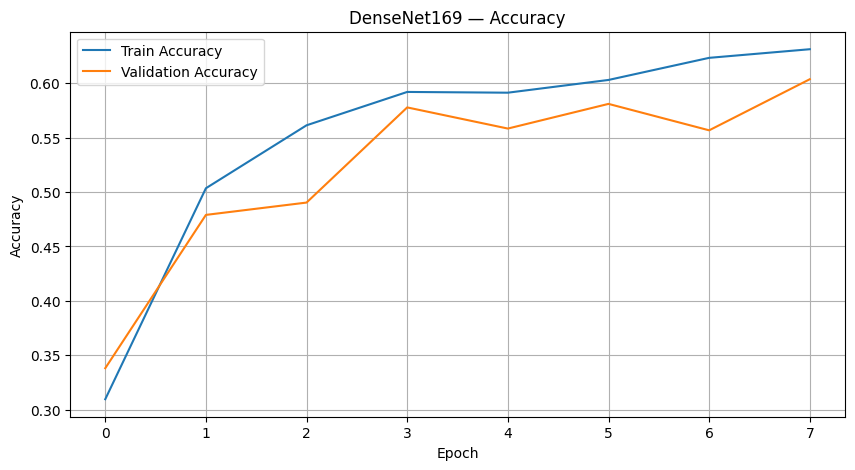

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet169 — Accuracy")
plt.legend()
plt.grid(True)

plt.show()

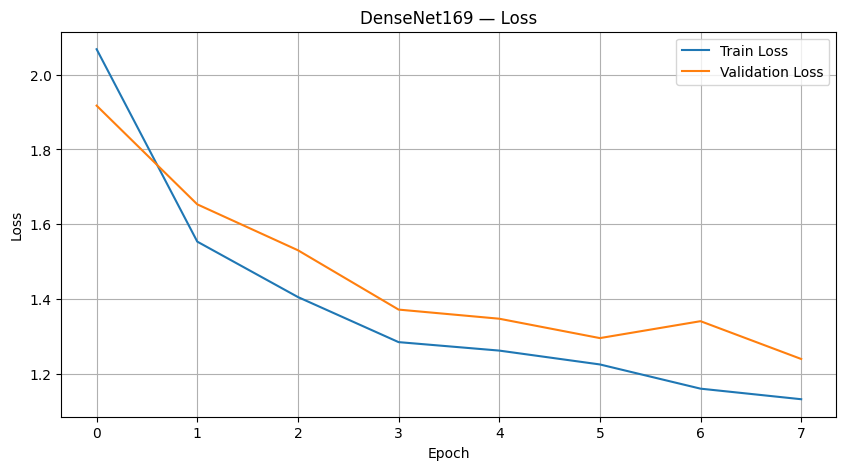

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet169 — Loss")
plt.legend()
plt.grid(True)

plt.show()

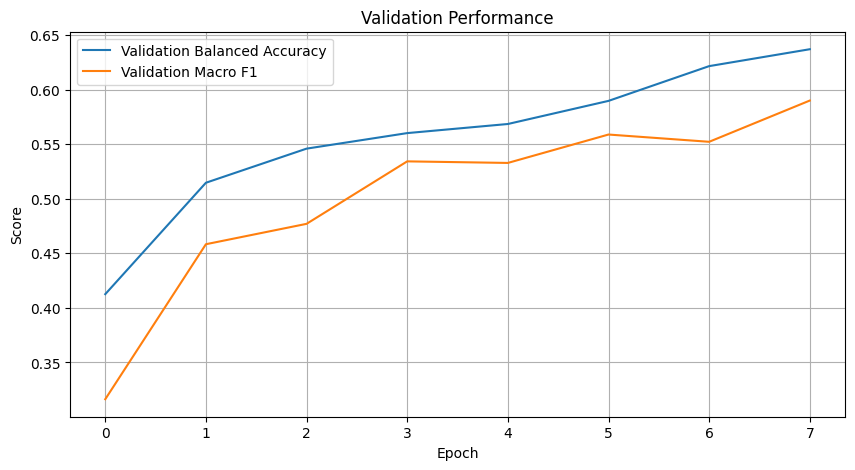

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["val_balanced_acc"],
    label="Validation Balanced Accuracy"
)

plt.plot(
    history["val_f1"],
    label="Validation Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance")
plt.legend()
plt.grid(True)

plt.show()

In [34]:
checkpoint = torch.load(
    "/content/brain_mri_densenet169_head_best.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Loaded best Phase 1 model"
)

print(
    "Best validation Macro F1:",
    checkpoint["best_val_macro_f1"]
)

Loaded best Phase 1 model
Best validation Macro F1: 0.5899619659741732


In [35]:
# ============================================================
# PHASE 2: FINE-TUNING
# ============================================================

# Freeze everything first
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze the later DenseNet blocks
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.features.norm5.parameters():
    param.requires_grad = True

# Classifier stays trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print("Trainable layers:")
for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

Trainable layers:
features.denseblock4.denselayer1.norm1.weight
features.denseblock4.denselayer1.norm1.bias
features.denseblock4.denselayer1.conv1.weight
features.denseblock4.denselayer1.norm2.weight
features.denseblock4.denselayer1.norm2.bias
features.denseblock4.denselayer1.conv2.weight
features.denseblock4.denselayer2.norm1.weight
features.denseblock4.denselayer2.norm1.bias
features.denseblock4.denselayer2.conv1.weight
features.denseblock4.denselayer2.norm2.weight
features.denseblock4.denselayer2.norm2.bias
features.denseblock4.denselayer2.conv2.weight
features.denseblock4.denselayer3.norm1.weight
features.denseblock4.denselayer3.norm1.bias
features.denseblock4.denselayer3.conv1.weight
features.denseblock4.denselayer3.norm2.weight
features.denseblock4.denselayer3.norm2.bias
features.denseblock4.denselayer3.conv2.weight
features.denseblock4.denselayer4.norm1.weight
features.denseblock4.denselayer4.norm1.bias
features.denseblock4.denselayer4.conv1.weight
features.denseblock4.denselaye

In [36]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=2,
    min_lr=1e-7
)

In [37]:
import time
import copy
import torch

NUM_EPOCHS_FINE = 12

best_fine_f1 = -1.0

best_fine_state = copy.deepcopy(
    model.state_dict()
)

fine_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_balanced_acc": [],
    "val_f1": []
}

print("=" * 80)
print("PHASE 2: FINE-TUNING DENSENET169")
print("=" * 80)

for epoch in range(NUM_EPOCHS_FINE):

    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        val_balanced_acc,
        val_f1,
        _,
        _
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_f1)

    fine_history["train_loss"].append(train_loss)
    fine_history["train_acc"].append(train_acc)
    fine_history["val_loss"].append(val_loss)
    fine_history["val_acc"].append(val_acc)
    fine_history["val_balanced_acc"].append(
        val_balanced_acc
    )
    fine_history["val_f1"].append(val_f1)

    elapsed = time.time() - start_time

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS_FINE}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Val Bal Acc: {val_balanced_acc:.4f} "
        f"| Val Macro F1: {val_f1:.4f} "
        f"| LR: {current_lr:.2e} "
        f"| {elapsed:.1f}s"
    )

    if val_f1 > best_fine_f1:

        best_fine_f1 = val_f1

        best_fine_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": train_dataset.classes,
                "class_to_idx": train_dataset.class_to_idx,
                "num_classes": NUM_CLASSES,
                "image_size": IMG_SIZE,
                "best_val_macro_f1": best_fine_f1
            },
            "/content/brain_mri_densenet169_best.pth"
        )

        print(
            f"  ✅ NEW BEST "
            f"(Macro F1: {best_fine_f1:.4f})"
        )

print("\n" + "=" * 80)
print("PHASE 2 COMPLETE")
print("=" * 80)

model.load_state_dict(
    best_fine_state
)

print(
    f"Best Fine-Tuning Validation Macro F1: "
    f"{best_fine_f1:.4f}"
)

PHASE 2: FINE-TUNING DENSENET169
Epoch [1/12] | Train Loss: 1.0654 | Train Acc: 0.6617 | Val Loss: 1.1373 | Val Acc: 0.6327 | Val Bal Acc: 0.6712 | Val Macro F1: 0.6183 | LR: 1.00e-05 | 32.0s
  ✅ NEW BEST (Macro F1: 0.6183)
Epoch [2/12] | Train Loss: 0.9831 | Train Acc: 0.6769 | Val Loss: 1.0830 | Val Acc: 0.6634 | Val Bal Acc: 0.7035 | Val Macro F1: 0.6469 | LR: 1.00e-05 | 28.6s
  ✅ NEW BEST (Macro F1: 0.6469)
Epoch [3/12] | Train Loss: 0.8445 | Train Acc: 0.7326 | Val Loss: 1.0319 | Val Acc: 0.6764 | Val Bal Acc: 0.7189 | Val Macro F1: 0.6656 | LR: 1.00e-05 | 28.6s
  ✅ NEW BEST (Macro F1: 0.6656)
Epoch [4/12] | Train Loss: 0.8523 | Train Acc: 0.7226 | Val Loss: 0.9683 | Val Acc: 0.6990 | Val Bal Acc: 0.7313 | Val Macro F1: 0.6845 | LR: 1.00e-05 | 29.0s
  ✅ NEW BEST (Macro F1: 0.6845)
Epoch [5/12] | Train Loss: 0.7727 | Train Acc: 0.7657 | Val Loss: 0.9249 | Val Acc: 0.7104 | Val Bal Acc: 0.7343 | Val Macro F1: 0.6929 | LR: 1.00e-05 | 28.8s
  ✅ NEW BEST (Macro F1: 0.6929)
Epoch [6/12]

In [38]:
checkpoint = torch.load(
    "/content/brain_mri_densenet169_best.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Loaded best model")
print(
    "Best validation Macro F1:",
    checkpoint["best_val_macro_f1"]
)

Loaded best model
Best validation Macro F1: 0.7551781265373297


In [39]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

(
    test_loss,
    test_accuracy,
    test_balanced_accuracy,
    test_macro_f1,
    test_labels,
    test_predictions
) = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)

print(f"Test Loss:             {test_loss:.4f}")
print(f"Test Accuracy:         {test_accuracy:.4f}")
print(f"Test Balanced Accuracy:{test_balanced_accuracy:.4f}")
print(f"Test Macro F1:         {test_macro_f1:.4f}")

FINAL TEST RESULTS
Test Loss:             0.6934
Test Accuracy:         0.7874
Test Balanced Accuracy:0.8223
Test Macro F1:         0.7863


In [40]:
print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE")
print("=" * 80)

report = classification_report(
    test_labels,
    test_predictions,
    target_names=train_dataset.classes,
    digits=4,
    zero_division=0
)

print(report)


PER-CLASS PERFORMANCE
                   precision    recall  f1-score   support

      Astrocitoma     0.7468    0.6860    0.7152        86
        Carcinoma     0.8293    0.8718    0.8500        39
       Ependimoma     0.5833    0.9130    0.7119        23
        Germinoma     0.5238    0.7333    0.6111        15
     Glioblastoma     0.6667    0.8750    0.7568        32
   Meduloblastoma     0.8182    0.8571    0.8372        21
       Meningioma     0.7890    0.6719    0.7257       128
      Neurocitoma     0.9608    0.7000    0.8099        70
           Normal     0.8452    0.8987    0.8712        79
Oligodendroglioma     0.8378    0.9118    0.8732        34
         Papiloma     0.7778    0.9459    0.8537        37
       Schwannoma     0.8382    0.8028    0.8201        71

         accuracy                         0.7874       635
        macro avg     0.7681    0.8223    0.7863       635
     weighted avg     0.8002    0.7874    0.7873       635



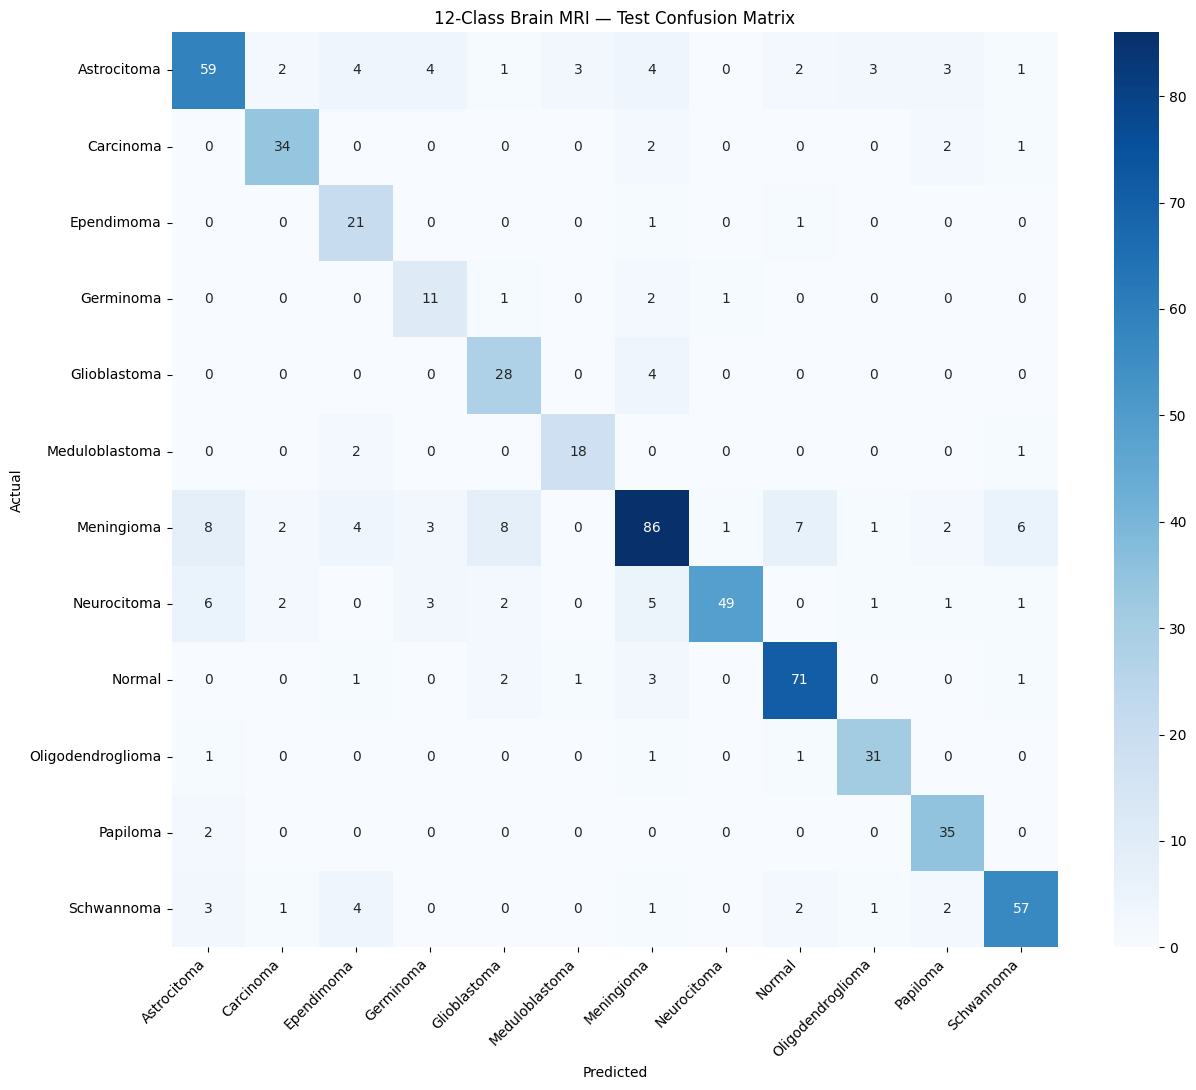

In [41]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(13, 11))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("12-Class Brain MRI — Test Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

FINAL_MODEL_PATH = "/content/brain_mri_densenet169_12class_final.pth"

checkpoint = {
    "model_state_dict": model.state_dict(),

    "class_names": train_dataset.classes,

    "class_to_idx": train_dataset.class_to_idx,

    "num_classes": NUM_CLASSES,

    "image_size": IMG_SIZE,

    "architecture": "DenseNet169",

    "test_accuracy": test_accuracy,

    "test_balanced_accuracy": test_balanced_accuracy,

    "test_macro_f1": test_macro_f1,

    "best_val_macro_f1": best_fine_f1
}

torch.save(
    checkpoint,
    FINAL_MODEL_PATH
)

print("=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(FINAL_MODEL_PATH)

print(
    f"Size: "
    f"{os.path.getsize(FINAL_MODEL_PATH) / (1024**2):.2f} MB"
)

MODEL SAVED
/content/brain_mri_densenet169_12class_final.pth
Size: 48.69 MB


Saving Glib.jpeg to Glib.jpeg
Uploaded: Glib.jpeg


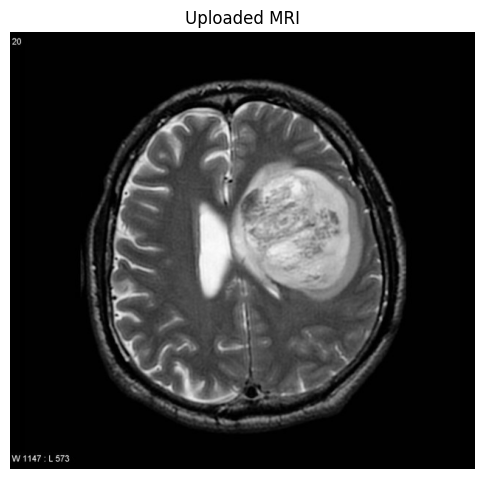


PREDICTION
Prediction : Neurocitoma
Confidence : 42.12%

Top predictions:
1. Neurocitoma               42.12%
2. Glioblastoma              19.77%
3. Meningioma                16.17%
4. Astrocitoma               11.62%
5. Oligodendroglioma         3.98%


In [47]:
from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ============================================================
# UPLOAD IMAGE
# ============================================================

uploaded = files.upload()

image_path = next(iter(uploaded))

print("Uploaded:", image_path)

# ============================================================
# LOAD IMAGE
# ============================================================

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Uploaded MRI")
plt.show()

# ============================================================
# PREPROCESS
# ============================================================

image_tensor = eval_transform(image)

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(device)

# ============================================================
# PREDICTION
# ============================================================

model.eval()

with torch.no_grad():

    output = model(image_tensor)

    probabilities = F.softmax(
        output,
        dim=1
    )[0]

# ============================================================
# TOP PREDICTION
# ============================================================

confidence, predicted_index = torch.max(
    probabilities,
    dim=0
)

predicted_class = train_dataset.classes[
    predicted_index.item()
]

print("\n" + "=" * 70)
print("PREDICTION")
print("=" * 70)

print(
    f"Prediction : {predicted_class}"
)

print(
    f"Confidence : {confidence.item() * 100:.2f}%"
)

# ============================================================
# TOP 5
# ============================================================

top_k = min(5, NUM_CLASSES)

top_probs, top_indices = torch.topk(
    probabilities,
    top_k
)

print("\nTop predictions:")

for rank, (prob, idx) in enumerate(
    zip(top_probs, top_indices),
    start=1
):

    print(
        f"{rank}. "
        f"{train_dataset.classes[idx.item()]:<25} "
        f"{prob.item() * 100:.2f}%"
    )

In [48]:
from google.colab import files

MODEL_PATH = "/content/brain_mri_densenet169_12class_final.pth"

files.download(MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
import torch
import os

V1_PATH = "/content/brain_mri_densenet169_12class_final.pth"

checkpoint = torch.load(
    V1_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("=" * 70)
print("V1 LOADED SUCCESSFULLY")
print("=" * 70)

print("Architecture:", checkpoint.get("architecture"))
print("Classes:", checkpoint["class_names"])
print(
    "Best validation Macro F1:",
    checkpoint.get("best_val_macro_f1")
)

V1 LOADED SUCCESSFULLY
Architecture: DenseNet169
Classes: ['Astrocitoma', 'Carcinoma', 'Ependimoma', 'Germinoma', 'Glioblastoma', 'Meduloblastoma', 'Meningioma', 'Neurocitoma', 'Normal', 'Oligodendroglioma', 'Papiloma', 'Schwannoma']
Best validation Macro F1: 0.7551781265373297


In [51]:
from torchvision import transforms

IMG_SIZE = 224

train_transform_v2 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=7
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.97, 1.03)
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [52]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [53]:
from torchvision import datasets
from torch.utils.data import DataLoader

DATASET_DIR = "/content/MRI_12_CLASS_CLEAN"

train_dataset_v2 = datasets.ImageFolder(
    f"{DATASET_DIR}/train",
    transform=train_transform_v2
)

val_dataset_v2 = datasets.ImageFolder(
    f"{DATASET_DIR}/val",
    transform=eval_transform
)

test_dataset_v2 = datasets.ImageFolder(
    f"{DATASET_DIR}/test",
    transform=eval_transform
)

print("Train:", len(train_dataset_v2))
print("Val:", len(val_dataset_v2))
print("Test:", len(test_dataset_v2))

print("\nClass mapping:")
print(train_dataset_v2.class_to_idx)

Train: 2906
Val: 618
Test: 635

Class mapping:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Germinoma': 3, 'Glioblastoma': 4, 'Meduloblastoma': 5, 'Meningioma': 6, 'Neurocitoma': 7, 'Normal': 8, 'Oligodendroglioma': 9, 'Papiloma': 10, 'Schwannoma': 11}


In [54]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler

targets = train_dataset_v2.targets

class_counts = Counter(targets)

sample_weights = []

for label in targets:

    sample_weights.append(
        1.0 / class_counts[label]
    )

sample_weights = torch.DoubleTensor(
    sample_weights
)

sampler_v2 = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("V2 sampler ready.")

V2 sampler ready.


In [55]:
BATCH_SIZE = 32

train_loader_v2 = DataLoader(
    train_dataset_v2,
    batch_size=BATCH_SIZE,
    sampler=sampler_v2,
    num_workers=2,
    pin_memory=True
)

val_loader_v2 = DataLoader(
    val_dataset_v2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_v2 = DataLoader(
    test_dataset_v2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    len(train_loader_v2),
    len(val_loader_v2),
    len(test_loader_v2)
)

91 20 20


In [56]:
class FocalLoss(nn.Module):

    def __init__(
        self,
        gamma=2.0,
        alpha=None,
        reduction="mean"
    ):
        super().__init__()

        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, targets):

        ce_loss = nn.functional.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        focal_loss = (
            (1 - pt) ** self.gamma
        ) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()

        elif self.reduction == "sum":
            return focal_loss.sum()

        return focal_loss

In [57]:
criterion_v2 = FocalLoss(gamma=2.0)

In [58]:
criterion_v2 = FocalLoss(
    gamma=2.0
)

print("V2 loss: Focal Loss")

V2 loss: Focal Loss


In [59]:
# Freeze entire backbone first

for param in model.features.parameters():
    param.requires_grad = False


# Unfreeze later blocks

for param in model.features.denseblock3.parameters():
    param.requires_grad = True

for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.features.norm5.parameters():
    param.requires_grad = True


# Classifier

for param in model.classifier.parameters():
    param.requires_grad = True


print("Trainable layers:")

for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

Trainable layers:
features.denseblock3.denselayer1.norm1.weight
features.denseblock3.denselayer1.norm1.bias
features.denseblock3.denselayer1.conv1.weight
features.denseblock3.denselayer1.norm2.weight
features.denseblock3.denselayer1.norm2.bias
features.denseblock3.denselayer1.conv2.weight
features.denseblock3.denselayer2.norm1.weight
features.denseblock3.denselayer2.norm1.bias
features.denseblock3.denselayer2.conv1.weight
features.denseblock3.denselayer2.norm2.weight
features.denseblock3.denselayer2.norm2.bias
features.denseblock3.denselayer2.conv2.weight
features.denseblock3.denselayer3.norm1.weight
features.denseblock3.denselayer3.norm1.bias
features.denseblock3.denselayer3.conv1.weight
features.denseblock3.denselayer3.norm2.weight
features.denseblock3.denselayer3.norm2.bias
features.denseblock3.denselayer3.conv2.weight
features.denseblock3.denselayer4.norm1.weight
features.denseblock3.denselayer4.norm1.bias
features.denseblock3.denselayer4.conv1.weight
features.denseblock3.denselaye

In [60]:
optimizer_v2 = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=5e-6,
    weight_decay=1e-4
)

scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

print("V2 optimizer ready.")

V2 optimizer ready.


In [61]:
NUM_EPOCHS_V2 = 15

best_v2_f1 = -1.0

best_v2_state = copy.deepcopy(
    model.state_dict()
)

v2_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_balanced_acc": [],
    "val_f1": []
}

print("=" * 80)
print("V2 TRAINING — DENSENET169 + FOCAL LOSS")
print("=" * 80)

for epoch in range(NUM_EPOCHS_V2):

    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader_v2,
        criterion_v2,
        optimizer_v2,
        device
    )

    (
        val_loss,
        val_acc,
        val_balanced_acc,
        val_f1,
        _,
        _
    ) = evaluate(
        model,
        val_loader_v2,
        criterion_v2,
        device
    )

    scheduler_v2.step(val_f1)

    v2_history["train_loss"].append(
        train_loss
    )

    v2_history["train_acc"].append(
        train_acc
    )

    v2_history["val_loss"].append(
        val_loss
    )

    v2_history["val_acc"].append(
        val_acc
    )

    v2_history["val_balanced_acc"].append(
        val_balanced_acc
    )

    v2_history["val_f1"].append(
        val_f1
    )

    elapsed = time.time() - start_time

    current_lr = optimizer_v2.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS_V2}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Val Bal Acc: {val_balanced_acc:.4f} "
        f"| Val Macro F1: {val_f1:.4f} "
        f"| LR: {current_lr:.2e} "
        f"| {elapsed:.1f}s"
    )

    if val_f1 > best_v2_f1:

        best_v2_f1 = val_f1

        best_v2_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": train_dataset_v2.classes,
                "class_to_idx": train_dataset_v2.class_to_idx,
                "num_classes": 12,
                "image_size": 224,
                "architecture": "DenseNet169",
                "version": "V2",
                "best_val_macro_f1": best_v2_f1
            },
            "/content/brain_mri_densenet169_v2_best.pth"
        )

        print(
            f"  ✅ NEW V2 BEST "
            f"(Macro F1: {best_v2_f1:.4f})"
        )


# Restore best V2

model.load_state_dict(
    best_v2_state
)

print("\n" + "=" * 80)
print("V2 TRAINING COMPLETE")
print("=" * 80)

print(
    f"Best V2 Validation Macro F1: "
    f"{best_v2_f1:.4f}"
)

V2 TRAINING — DENSENET169 + FOCAL LOSS
Epoch [1/15] | Train Loss: 0.2360 | Train Acc: 0.8627 | Val Loss: 0.3659 | Val Acc: 0.7913 | Val Bal Acc: 0.8032 | Val Macro F1: 0.7879 | LR: 5.00e-06 | 33.1s
  ✅ NEW V2 BEST (Macro F1: 0.7879)
Epoch [2/15] | Train Loss: 0.2173 | Train Acc: 0.8703 | Val Loss: 0.3412 | Val Acc: 0.8026 | Val Bal Acc: 0.8112 | Val Macro F1: 0.7971 | LR: 5.00e-06 | 30.7s
  ✅ NEW V2 BEST (Macro F1: 0.7971)
Epoch [3/15] | Train Loss: 0.1968 | Train Acc: 0.8741 | Val Loss: 0.3309 | Val Acc: 0.8074 | Val Bal Acc: 0.8188 | Val Macro F1: 0.7995 | LR: 5.00e-06 | 32.9s
  ✅ NEW V2 BEST (Macro F1: 0.7995)
Epoch [4/15] | Train Loss: 0.1764 | Train Acc: 0.8885 | Val Loss: 0.3076 | Val Acc: 0.8188 | Val Bal Acc: 0.8242 | Val Macro F1: 0.8099 | LR: 5.00e-06 | 30.4s
  ✅ NEW V2 BEST (Macro F1: 0.8099)
Epoch [5/15] | Train Loss: 0.1839 | Train Acc: 0.8944 | Val Loss: 0.2978 | Val Acc: 0.8236 | Val Bal Acc: 0.8285 | Val Macro F1: 0.8170 | LR: 5.00e-06 | 30.4s
  ✅ NEW V2 BEST (Macro F1:

In [62]:
V2_PATH = "/content/brain_mri_densenet169_v2_best.pth"

checkpoint_v2 = torch.load(
    V2_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint_v2["model_state_dict"]
)

print("=" * 70)
print("V2 BEST CHECKPOINT LOADED")
print("=" * 70)

print("Architecture:", checkpoint_v2["architecture"])
print("Version:", checkpoint_v2["version"])
print("Best validation Macro F1:",
      checkpoint_v2["best_val_macro_f1"])

V2 BEST CHECKPOINT LOADED
Architecture: DenseNet169
Version: V2
Best validation Macro F1: 0.8742920282710379


In [63]:
(
    test_loss_v2,
    test_accuracy_v2,
    test_balanced_accuracy_v2,
    test_macro_f1_v2,
    test_labels_v2,
    test_predictions_v2
) = evaluate(
    model,
    test_loader_v2,
    criterion_v2,
    device
)

print("=" * 80)
print("V2 FINAL TEST RESULTS")
print("=" * 80)

print(f"Test Loss:              {test_loss_v2:.4f}")
print(f"Test Accuracy:          {test_accuracy_v2:.4f}")
print(f"Test Balanced Accuracy: {test_balanced_accuracy_v2:.4f}")
print(f"Test Macro F1:           {test_macro_f1_v2:.4f}")

V2 FINAL TEST RESULTS
Test Loss:              0.2026
Test Accuracy:          0.8835
Test Balanced Accuracy: 0.8901
Test Macro F1:           0.8888


In [64]:
print("=" * 80)
print("V2 PER-CLASS PERFORMANCE")
print("=" * 80)

print(
    classification_report(
        test_labels_v2,
        test_predictions_v2,
        target_names=test_dataset_v2.classes,
        digits=4,
        zero_division=0
    )
)

V2 PER-CLASS PERFORMANCE
                   precision    recall  f1-score   support

      Astrocitoma     0.8690    0.8488    0.8588        86
        Carcinoma     0.9722    0.8974    0.9333        39
       Ependimoma     0.7692    0.8696    0.8163        23
        Germinoma     0.8462    0.7333    0.7857        15
     Glioblastoma     0.8333    0.9375    0.8824        32
   Meduloblastoma     0.9524    0.9524    0.9524        21
       Meningioma     0.8333    0.8203    0.8268       128
      Neurocitoma     0.9516    0.8429    0.8939        70
           Normal     0.8750    0.9747    0.9222        79
Oligodendroglioma     1.0000    0.9706    0.9851        34
         Papiloma     0.8974    0.9459    0.9211        37
       Schwannoma     0.8873    0.8873    0.8873        71

         accuracy                         0.8835       635
        macro avg     0.8906    0.8901    0.8888       635
     weighted avg     0.8855    0.8835    0.8833       635



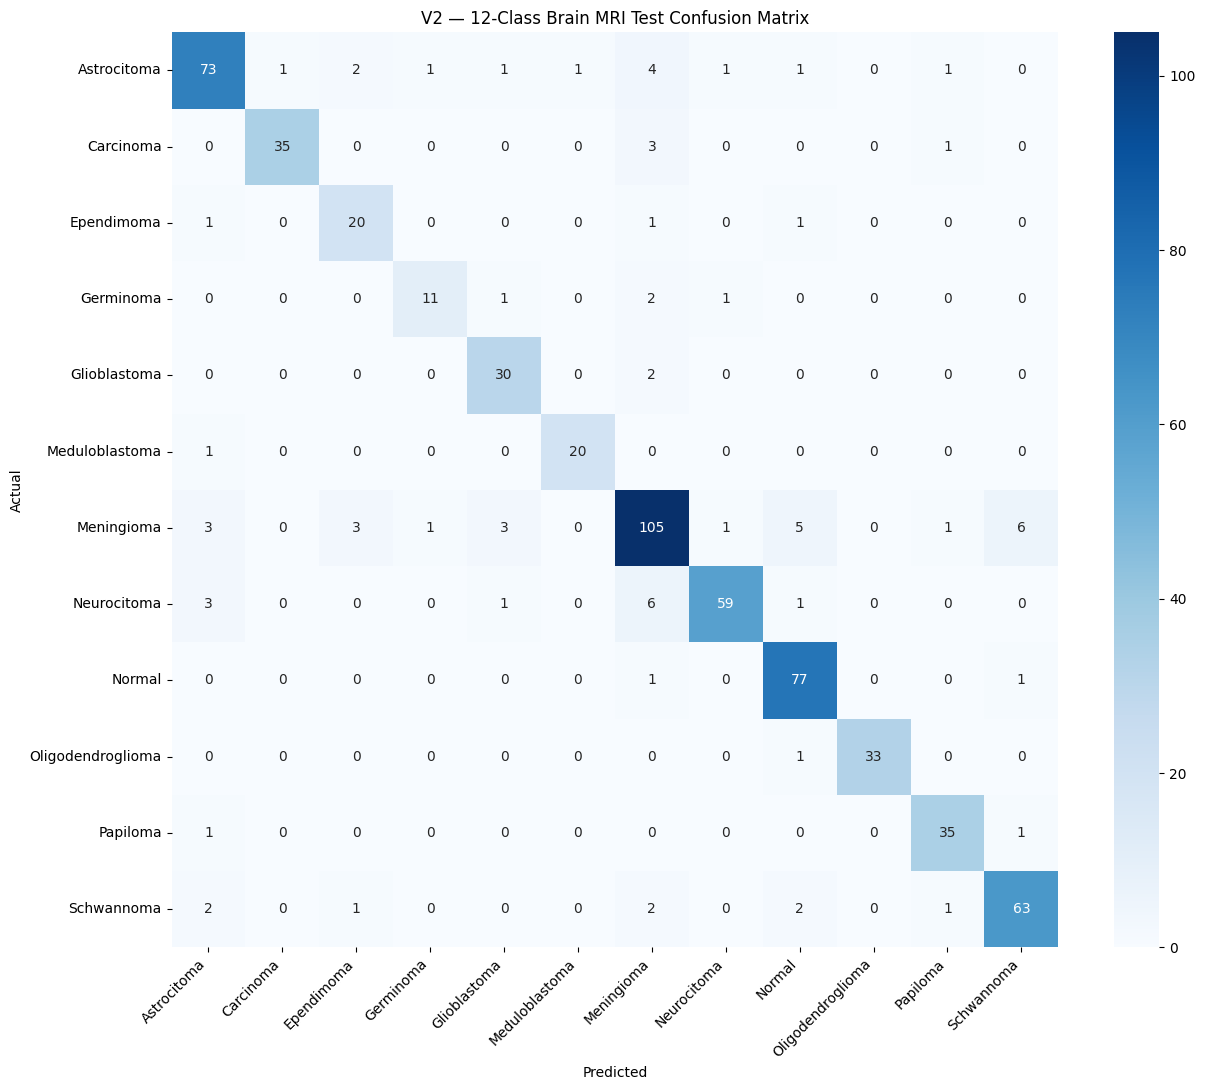

In [65]:
cm_v2 = confusion_matrix(
    test_labels_v2,
    test_predictions_v2
)

plt.figure(figsize=(13, 11))

sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset_v2.classes,
    yticklabels=test_dataset_v2.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "V2 — 12-Class Brain MRI Test Confusion Matrix"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [66]:
import torch
import os

FINAL_V2_PATH = "/content/brain_mri_densenet169_12class_V2_FINAL.pth"

final_checkpoint = {
    "model_state_dict": model.state_dict(),

    "architecture": "DenseNet169",

    "version": "V2",

    "num_classes": 12,

    "image_size": 224,

    "class_names": test_dataset_v2.classes,

    "class_to_idx": test_dataset_v2.class_to_idx,

    "test_accuracy": float(test_accuracy_v2),

    "test_balanced_accuracy": float(test_balanced_accuracy_v2),

    "test_macro_f1": float(test_macro_f1_v2),

    "best_val_macro_f1": float(
        checkpoint_v2["best_val_macro_f1"]
    ),

    "normalization": {
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225]
    }
}

torch.save(
    final_checkpoint,
    FINAL_V2_PATH
)

print("=" * 70)
print("FINAL V2 MODEL SAVED")
print("=" * 70)

print(FINAL_V2_PATH)

print(
    "Size:",
    f"{os.path.getsize(FINAL_V2_PATH) / (1024**2):.2f} MB"
)

FINAL V2 MODEL SAVED
/content/brain_mri_densenet169_12class_V2_FINAL.pth
Size: 48.70 MB


In [67]:
from google.colab import files

files.download(
    "/content/brain_mri_densenet169_12class_V2_FINAL.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving schew.jpg to schew.jpg

Testing: schew.jpg


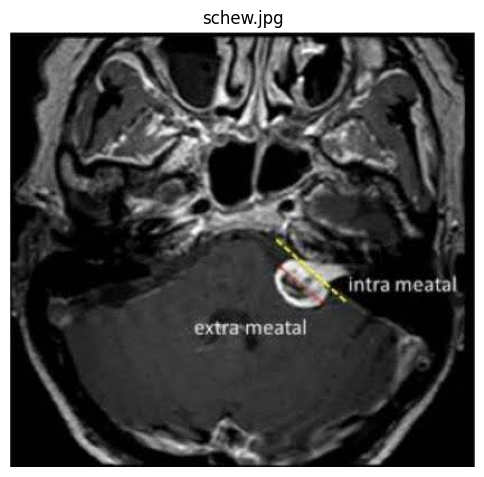


Prediction : Schwannoma
Confidence : 33.00%

Top 5 predictions:
1. Schwannoma             33.00%
2. Astrocitoma            18.65%
3. Papiloma               16.18%
4. Meningioma             11.61%
5. Meduloblastoma         10.10%


In [78]:
from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ============================================================
# V2 MRI CLASSIFIER — UPLOAD & TEST
# ============================================================

uploaded = files.upload()

for image_path in uploaded.keys():

    print("\n" + "=" * 70)
    print(f"Testing: {image_path}")
    print("=" * 70)

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Display
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_path)
    plt.show()

    # Same preprocessing used during testing
    image_tensor = eval_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = F.softmax(output, dim=1)[0]

    # Top prediction
    confidence, predicted_index = torch.max(
        probabilities,
        dim=0
    )

    predicted_class = test_dataset_v2.classes[
        predicted_index.item()
    ]

    print(f"\nPrediction : {predicted_class}")
    print(
        f"Confidence : "
        f"{confidence.item() * 100:.2f}%"
    )

    # Top 5
    top_k = min(5, len(test_dataset_v2.classes))

    top_probs, top_indices = torch.topk(
        probabilities,
        top_k
    )

    print("\nTop 5 predictions:")

    for rank, (prob, idx) in enumerate(
        zip(top_probs, top_indices),
        start=1
    ):
        print(
            f"{rank}. "
            f"{test_dataset_v2.classes[idx.item()]:<22}"
            f"{prob.item() * 100:6.2f}%"
        )